<a href="https://colab.research.google.com/github/islombek-cs/Computer-Vision-Labs/blob/main/Week_11_Lab_%E2%80%94_Generative_Models_II_Diffusion_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Islombek Abdurakhmanov  
**ID:** 221236  
**Shared Colab Link:** https://colab.research.google.com/drive/1vcq-l2s0n0YL8wr7eMz_XVK9xDuy61nc?usp=sharing

# Week 11 Lab — Generative Models II: Diffusion Models

*Forward/Reverse Diffusion • DDPMs • Latent Diffusion • Text-to-Image Synthesis*

This lab is fully runnable in Google Colab (GPU recommended).
I include:

✅ Learning goals

✅ Background diagrams (ASCII)

✅ Hands-on coding:

* Forward diffusion
* Reverse sampling with a tiny DDPM
* Using HuggingFace diffusers (Stable Diffusion)
* Latent diffusion visualization
* Text-to-image generation
* Optional bonus exercises

## Lab Learning Objectives

By the end of this lab, students will:

* Implement forward diffusion noise schedule
* Implement a minimal DDPM sampling loop
* Understand the reverse denoising process
* Generate images using Stable Diffusion (Latent Diffusion)
* Visualize latent space and manipulate latents
* Perform text-to-image synthesis






In [3]:
# ==============================================
# 📦 Setup
# ==============================================
!pip install -q diffusers transformers accelerate safetensors
import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from PIL import Image


## Part 1 — Forward Diffusion (Noise Schedule)

Forward diffusion gradually destroys an image with Gaussian noise.

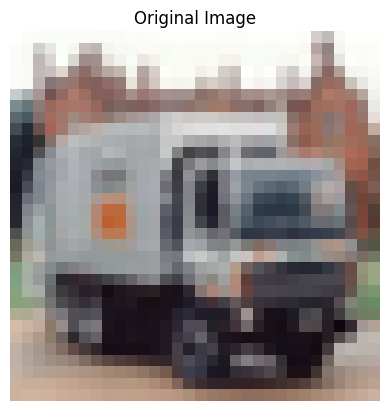

In [4]:
# Load a simple image (CIFAR-10 example)
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
x0, _ = dataset[11]  # pick a sample
x0 = x0.unsqueeze(0)

plt.imshow(np.transpose(x0[0], (1,2,0)))
plt.title("Original Image")
plt.axis("off")
plt.show()


Noise schedule (βₜ)

In [5]:
T = 200  # total diffusion steps
beta = torch.linspace(1e-4, 0.02, T)
alpha = 1 - beta
alpha_hat = torch.cumprod(alpha, dim=0)


Add noise at step t

In [6]:
def forward_diffusion_sample(x0, t):
    noise = torch.randn_like(x0)
    sqrt_alpha_hat = alpha_hat[t].sqrt().view(-1, 1, 1, 1)
    sqrt_one_minus = (1 - alpha_hat[t]).sqrt().view(-1, 1, 1, 1)
    return sqrt_alpha_hat * x0 + sqrt_one_minus * noise, noise


Visualize gradually noising an image

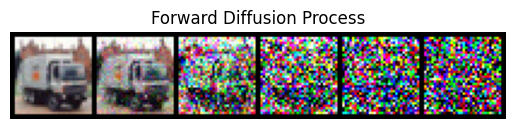

In [7]:
imgs = []
for t in [1, 10, 50, 100, 150, 199]:
    noisy_img, _ = forward_diffusion_sample(x0, t)
    imgs.append(noisy_img[0])

grid = make_grid(imgs, nrow=6)
plt.imshow(np.transpose(grid, (1,2,0)))
plt.title("Forward Diffusion Process")
plt.axis("off")
plt.show()


## Part 2 — Tiny DDPM Reverse Sampling

We implement a small U-Net to predict noise.
(We won’t train it — we will use random weights just to illustrate the mechanism.)

Minimal UNet-like noise predictor

In [8]:
class TinyUnet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 3, 3, padding=1)
        )
    def forward(self, x, t):
        return self.net(x)

model = TinyUnet()


Reverse Sampling

In [9]:
@torch.no_grad()
def reverse_sample(model, shape):
    img = torch.randn(shape)
    for t in reversed(range(1, T)):
        z = torch.randn_like(img) if t > 1 else 0
        predicted_noise = model(img, t)

        img = (1/alpha[t].sqrt()) * (img - beta[t] / (1-alpha_hat[t]).sqrt() * predicted_noise) + beta[t].sqrt()*z
    return img


Generate a sample (random model → abstract images)

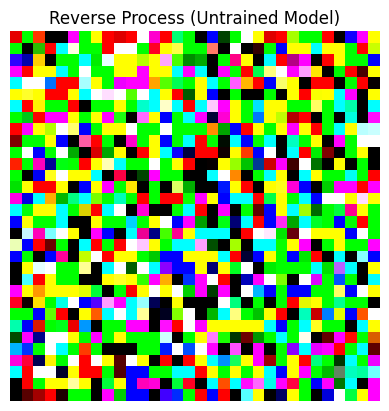

In [10]:
sample = reverse_sample(model, (1,3,32,32))[0]
plt.imshow(np.transpose(sample, (1,2,0)).clip(0,1))
plt.title("Reverse Process (Untrained Model)")
plt.axis("off")
plt.show()


## Part 3 — Latent Diffusion (Stable Diffusion)

Now we switch to real, pretrained diffusion:
Stable Diffusion = Diffusion in latent space, not pixel space.

In [11]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU ONLY")


CUDA available: False
Device: CPU ONLY


## Part 4 — Text-to-Image Generation

In [12]:
from diffusers import StableDiffusionPipeline
import torch

if not torch.cuda.is_available():
    print("CUDA not available, running on CPU.")

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
).to("cuda" if torch.cuda.is_available() else "cpu")

CUDA not available, running on CPU.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


## Part 5 — Inspect Latent Space

In [14]:
import torch

# Encode prompt → latent
prompt = "a cute red panda eating ramen"
latents = torch.randn((1, pipe.unet.in_channels, 64, 64)).half().to("cpu")

# Show statistics
print("Latent shape:", latents.shape)
print("Mean:", latents.mean().item())
print("Std:", latents.std().item())

Latent shape: torch.Size([1, 4, 64, 64])
Mean: -0.021759033203125
Std: 1.00390625


/tmp/ipython-input-1682813067.py:5: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  latents = torch.randn((1, pipe.unet.in_channels, 64, 64)).half().to("cpu")


Students can modify latents to change style.

## Part 6 — Generate Multiple Samples

  0%|          | 0/50 [00:00<?, ?it/s]

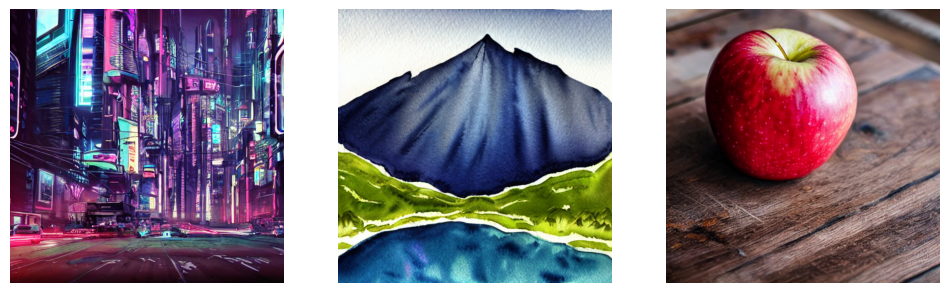

In [15]:
prompts = [
    "photo of a cyberpunk city",
    "a watercolor painting of a mountain",
    "a hyperrealistic apple on a table"
]

images = pipe(prompts).images
plt.figure(figsize=(12,4))
for i,img in enumerate(images):
    plt.subplot(1,3,i+1)
    plt.imshow(img); plt.axis("off")
plt.show()
